In [1]:
import numpy as np
from matplotlib import pyplot as plt
from scipy import integrate as integrate
from scipy.interpolate import interp1d as interp1d
import pandas as pd


# rs [kpc] rho [GeV/cm3]
#NFW 􀀀 24.42 0.184
#Einasto 0.17 28.44 0.033
#EinastoB 0.11 35.24 0.021
#Isothermal 􀀀 4.38 1.387
#Burkert 􀀀 12.67 0.712
#Moore 􀀀 30.28 0.105
[rs_1, rho_1, 
 rs_2, rho_2, 
 rs_3, rho_3, 
 rs_4, rho_4, 
 rs_5, rho_5, 
 rs_6, rho_6] = [24.42, 0.184,
  28.44, 0.033,
  35.24, 0.021,
4.38, 1.387,
12.67, 0.712,
 30.28, 0.105] 
[alpha_1, alpha_2] = [0.17, 0.11]

r_Sun = 8.33
rho_Sun = 0.3
p = np.pi/180. # converts degrees to radians

#s_int = np.logspace(-4,2.3,500000)
#theta_region = np.logspace(-10,np.log10(np.pi+1e-10), 1000)
#uploaded = files.upload()

In [2]:
#image_core = open(r'J_Bur_ann.txt','r')
image_cusp = open(r'J_Moo_ann.txt','r')
#image_core_header1 = image_core.readline()
#image_core_header2 = image_core.readline().split()
image_cusp_header1 = image_cusp.readline()
image_cusp_header2 = image_cusp.readline().split()

param = 8*[0]
for i in range(8):
    param[i] = float(image_cusp_header2[i])

[dl, db, li, lf, bi, bf, nl, nb] = param
[nl, nb] = [int(nl), int(nb)]
b = np.arange(bi, bf + db, db)
l = np.arange(li, lf + dl, dl)
b = b.reshape([nb, 1])
[b_rad, l_rad] = [p*b, p*l]
th =  np.arccos(np.cos(b_rad)*np.cos(l_rad))

#J_core = np.zeros([nb,nl])
J_cusp = np.zeros([nb,nl])

for j in range(nb):
    #line_core = image_core.readline()                
    #columns_core = line_core.split()
    line_cusp = image_cusp.readline()                
    columns_cusp = line_cusp.split()
    for i in range(nl):
        
        #print(np.shape(Imagem[a][b]),np.shape(columns))
        #J_core[j][i] = float(columns_core[i])
        J_cusp[j][i] = float(columns_cusp[i])


#image_core.close()
image_cusp.close() 


In [3]:
def J_regions(filename):
    J = open(filename,'r')

    J.readline()
    J.readline()
    j_header = J.readline().split()
    data = []
    
    for line in J:
        numbers = line.split()
        #name = numbers[0]
        numbers = [float(n) for n in numbers[1:]]
        #numbers = [name]+numbers
        data.append(numbers)
        
    J.close()
    data = np.array(data)    
    data = pd.DataFrame(data,columns=j_header[1:])
    return data[j_header[1]],data[j_header[2]] # region name, solid angle, J-factor

In [5]:
Gamma = open(r'AtProduction_gammas.dat','r')

gamma_header = Gamma.readline().split()
spectra = []

for line in Gamma:
    numbers = line.split()
    numbers = [float(n) for n in numbers]
    spectra.append(numbers)

Gamma.close()
spectra = np.array(spectra)    
spectra = pd.DataFrame(spectra,columns=gamma_header)

m1 = spectra['mDM'] == 1e2 
m2 = spectra['mDM'] == 1e3
m3 = spectra['mDM'] == 1e4
gamma1 = spectra[m1]
gamma2 = spectra[m2]
gamma3 = spectra[m3]

# obtaining energy [TeV]
E1 = 1e-1*np.power(10,gamma1['Log[10,x]'])
E2 = 1e-0*np.power(10,gamma2['Log[10,x]'])
E3 = 1e+1*np.power(10,gamma3['Log[10,x]'])

dN1 = gamma1.divide(np.log(10))
dN2 = gamma2.divide(np.log(10))
dN3 = gamma3.divide(np.log(10))

[dN1_W, dN1_Mu, dN1_b ]= [dN1['W'], dN1['\[Mu]'], dN1['b']]
[dN2_W, dN2_Mu, dN2_b ]= [dN2['W'], dN2['\[Mu]'], dN2['b']]
[dN3_W, dN3_Mu, dN3_b ]= [dN3['W'], dN3['\[Mu]'], dN3['b']]


In [6]:
def dNdE(filename,mass,channel): # mass in GeV
    Gamma = open(filename,'r')

    gamma_header = Gamma.readline().split()
    spectra = []

    for line in Gamma:
        numbers = line.split()
        numbers = [float(n) for n in numbers]
        spectra.append(numbers)

    Gamma.close()
    spectra = np.array(spectra)    
    spectra = pd.DataFrame(spectra,columns=gamma_header)
    m = spectra['mDM'] == mass
    gamma = spectra[m]
    E = mass*np.power(10,gamma['Log[10,x]'])
    dN = gamma.divide(np.log(10))
    return np.array(E), np.array(dN[channel].divide(E)) # GeV, GeV^-1
    

In [77]:
E, dN = dNdE('AtProduction_gammas.dat',1e3,'\[Mu]')

Calculating numerically $\int J d \Omega$:
\begin{equation}
  \int J d \Omega ≈ \sum J  \cos{b} \, db \, dl = 
   db \, dl \, \sum J \cos{b} = p^2 db[°] \, dl [°] \, np.sum(J[matrix])
\end{equation} 

Where $p$ is the degrees to radians conversion factor 

In [53]:
# We are now using CGS units: erg, g, cm, s
TeV_erg = 1.60218
pc_cm = 3.086e18
c = 2.9979245800e10 

# cross section - velocity:
sigma = 3e-26

# mDM1 = 100 GeV 
# mDM2 = 1000 GeV
# m DM3 = 10000 GeV
# Dark Matter masses in GeV:
mDM1 = 1e2
mDM2 = 1e3
mDM3 = 1e4 

# Dark Matter density is already in GeV/cm3
#const1 = r_Sun*(8*np.pi)**(-1) * (rho_Sun/mDM1)**2 * pc_cm
#const2 = r_Sun*(8*np.pi)**(-1) * (rho_Sun/mDM2)**2 * pc_cm
#const3 = r_Sun*(8*np.pi)**(-1) * (rho_Sun/mDM3)**2 * pc_cm

In [11]:
CTA = open(r"CTA-Performance-prod3b-v2-South-20deg-50h-DiffSens.txt",'r')

header_CTA = []
data_CTA = []
for i in range(10):
  header_CTA.append(CTA.readline())

for line in CTA:
  numbers = line.split()
  numbers = [float(n) for n in numbers]
  data_CTA.append(numbers)

Sens_CTA = pd.DataFrame(data_CTA,columns= ['E1','E2','S'])
CTA.close()

In [12]:
Sens_CTA

,E1,E2,S
0,0.0200,0.0316,2.180000e-11
1,0.0316,0.0501,6.940000e-12
2,0.0501,0.0794,1.830000e-12
3,0.0794,0.1260,7.970000e-13
4,0.1260,0.2000,4.630000e-13
5,0.2000,0.3160,2.890000e-13
6,0.3160,0.5010,1.980000e-13
7,0.5010,0.7940,1.440000e-13
8,0.7940,1.2600,9.670000e-14
9,1.2600,2.0000,8.120000e-14


In [56]:
uploaded = files.upload()

NameError: name 'files' is not defined

In [13]:
FERMI = open(r"FERMI_Sensitivity.txt",'r')

header_FERMI = []
data_FERMI = []
for i in range(5):
  header_FERMI.append(FERMI.readline())

for line in FERMI:
  numbers = line.split()
  numbers = [float(n) for n in numbers]
  data_FERMI.append(numbers)

Sens_FERMI = pd.DataFrame(data_FERMI,columns= ['E1','E2','S','Error'])
FERMI.close()

In [14]:
Sens_FERMI

,E1,E2,S,Error
0,31.622777,56.234133,1.900070e-11,0.0
1,56.234133,100.000000,1.549856e-11,0.0
2,100.000000,177.827941,1.302078e-11,0.0
3,177.827941,316.227766,1.149279e-11,0.0
4,316.227766,562.341325,9.351305e-12,0.0
5,562.341325,1000.000000,7.253778e-12,0.0
6,1000.000000,1778.279410,5.476409e-12,0.0
7,1778.279410,3162.277660,4.185778e-12,0.0
8,3162.277660,5623.413252,3.542805e-12,0.0
9,5623.413252,10000.000000,2.730846e-12,0.0


NameError: name 'const1' is not defined

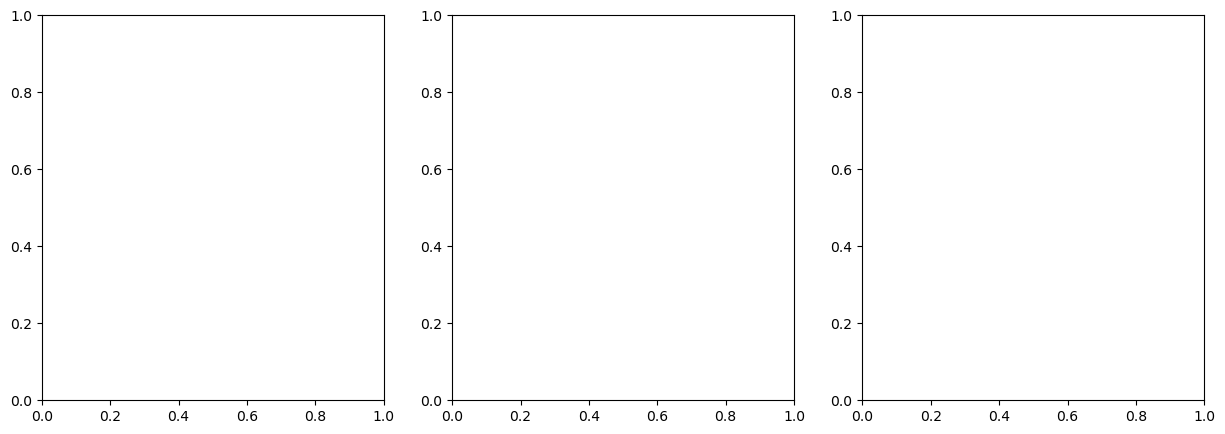

In [93]:
fig, axs = plt.subplots(1,3,figsize=(15,5))

#region 10
axs[0].plot(E1,dN1_W*E1*TeV_erg*const1*J10_cusp*sigma,label='$W^+ W^-$',color='blue',linestyle='solid')
axs[0].plot(E1,dN1_Mu*E1*TeV_erg*const1*J10_cusp*sigma,label='$\mu^+ \mu^-$',color='green',linestyle='solid')
axs[0].plot(E1,dN1_b*E1*TeV_erg*const1*J10_cusp*sigma,label='$b$',color='red',linestyle='solid')

axs[0].errorbar(np.sqrt(Sens_CTA['E1'].multiply(Sens_CTA['E2'])), Sens_CTA['S'],xerr = 0.5*(-Sens_CTA['E1']+Sens_CTA['E2']),fmt = '',label='CTA')
axs[1].errorbar(np.sqrt(Sens_CTA['E1'].multiply(Sens_CTA['E2'])), Sens_CTA['S'],xerr = 0.5*(-Sens_CTA['E1']+Sens_CTA['E2']),fmt = '')
axs[2].errorbar(np.sqrt(Sens_CTA['E1'].multiply(Sens_CTA['E2'])), Sens_CTA['S'],xerr = 0.5*(-Sens_CTA['E1']+Sens_CTA['E2']),fmt = '')
axs[0].errorbar(np.sqrt(1e-6*Sens_FERMI['E1'].multiply(1e-6*Sens_FERMI['E2'])), Sens_FERMI['S'],xerr = 0.5*1e-6*(-Sens_FERMI['E1']+Sens_FERMI['E2']),fmt = '',label='Fermi-LAT')
axs[1].errorbar(np.sqrt(1e-6*Sens_FERMI['E1'].multiply(1e-6*Sens_FERMI['E2'])), Sens_FERMI['S'],xerr = 0.5*1e-6*(-Sens_FERMI['E1']+Sens_FERMI['E2']),fmt = '',label='Fermi-LAT')
axs[2].errorbar(np.sqrt(1e-6*Sens_FERMI['E1'].multiply(1e-6*Sens_FERMI['E2'])), Sens_FERMI['S'],xerr = 0.5*1e-6*(-Sens_FERMI['E1']+Sens_FERMI['E2']),fmt = '',label='Fermi-LAT')

#axs[0].errorbar(0.5*(Sens_CTA['E1']+Sens_CTA['E2']), Sens_CTA['S'],xerr = 0.5*(-Sens_CTA['E1']+Sens_CTA['E2']),fmt = '.k')
#axs[0].errorbar(0.5*(Sens_CTA['E1']+Sens_CTA['E2']), Sens_CTA['S'],xerr = np.sqrt(Sens_CTA['E2'].divide(Sens_CTA['E1'])),fmt = 'o')

axs[1].plot(E2,dN2_W*E2*TeV_erg*const2*J10_cusp*sigma,label='$W^+ W^-$',color='blue',linestyle='solid')
axs[1].plot(E2,dN2_Mu*E2*TeV_erg*const2*J10_cusp*sigma,label='$W^+ W^-$',color='green',linestyle='solid')
axs[1].plot(E2,dN2_b*E2*TeV_erg*const2*J10_cusp*sigma,label='$W^+ W^-$',color='red',linestyle='solid')

axs[2].plot(E3,dN3_W*E3*TeV_erg*const3*J10_cusp*sigma,label='$W^+ W^-$',color='blue',linestyle= 'solid')
axs[2].plot(E3,dN3_Mu*E3*TeV_erg*const3*J10_cusp*sigma,label='$W^+ W^-$',color='green',linestyle='solid')
axs[2].plot(E3,dN3_b*E3*TeV_erg*const3*J10_cusp*sigma,label='$W^+ W^-$',color='red',linestyle='solid')

axs[0].set_xscale('log')
axs[0].set_yscale('log')
axs[1].set_xscale('log')
axs[1].set_yscale('log')
axs[2].set_xscale('log')
axs[2].set_yscale('log')

axs[0].set_ylim(1e-18,1e-10)
axs[1].set_ylim(1e-18,1e-10)
axs[2].set_ylim(1e-18,1e-10)

axs[0].set_xlim(1e-4,1e2)
axs[1].set_xlim(1e-4,1e2)
axs[2].set_xlim(1e-4,1e2)

axs[0].set_xlabel(r'$E \, [ TeV]$',fontsize=12)
axs[1].set_xlabel(r'$E \, [ TeV]$',fontsize=12)
axs[2].set_xlabel(r'$E \, [ TeV]$',fontsize=12)
axs[0].set_ylabel(r'$E^2 \, Flux \, [erg \, cm^{-2} \, s^{-1}]$'+'\n'+r'$\theta < 1.0°$',fontsize=13)

axs[0].set_title("$m_{DM} = 100 \, GeV$")
axs[1].set_title("$m_{DM} = 1000 \, GeV$")
axs[2].set_title("$m_{DM} = 10,000 \, GeV$")

xlabel = ['$10^{-4}$','$10^{-4}$','$10^{-3}$','$10^{-2}$','$10^{-1}$','$10^0$','$10^{1}$','$10^{2}$']
ylabel = ['$10^{-18}$','$10^{-18}$','$10^{-16}$','$10^{-14}$','$10^{-12}$','$10^{-10}$']
axs[0].set_xticklabels(xlabel[0:],fontsize=12)
axs[1].set_xticklabels(xlabel[0:],fontsize=12)
axs[2].set_xticklabels(xlabel[0:],fontsize=12)

fig.suptitle('DM annihilation Fluxes around the GC',fontsize=15)

axs[0].legend()

In [8]:
# We are now using CGS units: erg, g, cm, s
TeV_erg = 1.60218
pc_cm = 3.086e18
c = 2.9979245800e10 

# cross section - velocity:
sigma = 3e-26

# mDM1 = 100 GeV 
# mDM2 = 1000 GeV
# m DM3 = 10000 GeV
# Dark Matter masses in GeV:
mDM1 = 1e2
mDM2 = 1e3
mDM3 = 1e4 

# Dark Matter density is already in GeV/cm3
#const1 = r_Sun*(8*np.pi)**(-1) * (rho_Sun/mDM1)**2 * pc_cm
#const2 = r_Sun*(8*np.pi)**(-1) * (rho_Sun/mDM2)**2 * pc_cm
#const3 = r_Sun*(8*np.pi)**(-1) * (rho_Sun/mDM3)**2 * pc_cm


[solid,J] = J_regions('J_GC_EinastoCTA.dat')
J = np.sum(J)

E1, dN1_W = dNdE('AtProduction_gammas.dat',mDM1,'W')
dN1_mu = dNdE('AtProduction_gammas.dat',mDM1,'\[Mu]')[1]
dN1_b = dNdE('AtProduction_gammas.dat',mDM1,'b')[1]

E2, dN2_W = dNdE('AtProduction_gammas.dat',mDM2,'W')
dN2_mu = dNdE('AtProduction_gammas.dat',mDM2,'\[Mu]')[1]
dN2_b = dNdE('AtProduction_gammas.dat',mDM2,'b')[1]

E3, dN3_W = dNdE('AtProduction_gammas.dat',mDM3,'W')
dN3_mu = dNdE('AtProduction_gammas.dat',mDM3,'\[Mu]')[1]
dN3_b = dNdE('AtProduction_gammas.dat',mDM3,'b')[1]



Phi1_W = sigma*dN1_W*J/(8.*np.pi*mDM1**2.)*1e3 # TeV^-1 cm^-2 s^-1 
Phi1_mu = sigma*dN1_mu*J/(8.*np.pi*mDM1**2.)*1e3 
Phi1_b = sigma*dN1_b*J/(8.*np.pi*mDM1**2.)*1e3

Phi2_W = sigma*dN2_W*J/(8.*np.pi*mDM2**2.)*1e3 
Phi2_mu = sigma*dN2_mu*J/(8.*np.pi*mDM2**2.)*1e3 
Phi2_b = sigma*dN2_b*J/(8.*np.pi*mDM2**2.)*1e3

Phi3_W = sigma*dN3_W*J/(8.*np.pi*mDM3**2.)*1e3 
Phi3_mu = sigma*dN3_mu*J/(8.*np.pi*mDM3**2.)*1e3 
Phi3_b = sigma*dN3_b*J/(8.*np.pi*mDM3**2.)*1e3


In [9]:
Phi2_W*

SyntaxError: invalid syntax (2407103151.py, line 1)

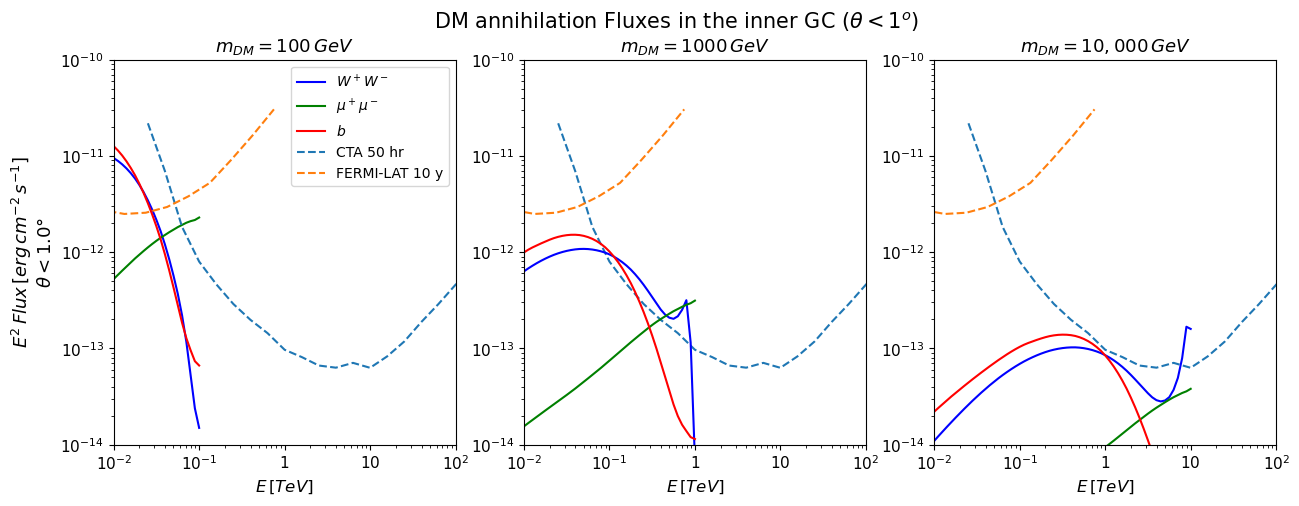

In [16]:
fig, axs = plt.subplots(1,3,figsize=(15,5))

#region 10
axs[0].plot(1e-3*E1,1e-6*Phi1_W*E1**2.*TeV_erg,label='$W^+ W^-$',color='blue',linestyle='solid')
axs[0].plot(1e-3*E1,1e-6*Phi1_mu*E1**2.*TeV_erg,label='$\mu^+ \mu^-$',color='green',linestyle='solid')
axs[0].plot(1e-3*E1,1e-6*Phi1_b*E1**2.*TeV_erg,label='$b$',color='red',linestyle='solid')

#axs[0].errorbar(0*np.sqrt(Sens_CTA['E1'].multiply(Sens_CTA['E2'])), Sens_CTA['S'],xerr = 0.5*(-Sens_CTA['E1']+Sens_CTA['E2']),fmt = '',label='CTA')
#axs[1].errorbar(np.sqrt(Sens_CTA['E1'].multiply(Sens_CTA['E2'])), Sens_CTA['S'],xerr = 0.5*(-Sens_CTA['E1']+Sens_CTA['E2']),fmt = '')
#axs[2].errorbar(np.sqrt(Sens_CTA['E1'].multiply(Sens_CTA['E2'])), Sens_CTA['S'],xerr = 0.5*(-Sens_CTA['E1']+Sens_CTA['E2']),fmt = '')
#axs[0].errorbar(np.sqrt(1e-6*Sens_FERMI['E1'].multiply(1e-6*Sens_FERMI['E2'])), Sens_FERMI['S'],xerr = 0.5*1e-6*(-Sens_FERMI['E1']+Sens_FERMI['E2']),fmt = '',label='Fermi-LAT')
#axs[1].errorbar(np.sqrt(1e-6*Sens_FERMI['E1'].multiply(1e-6*Sens_FERMI['E2'])), Sens_FERMI['S'],xerr = 0.5*1e-6*(-Sens_FERMI['E1']+Sens_FERMI['E2']),fmt = '',label='Fermi-LAT')
#axs[2].errorbar(np.sqrt(1e-6*Sens_FERMI['E1'].multiply(1e-6*Sens_FERMI['E2'])), Sens_FERMI['S'],xerr = 0.5*1e-6*(-Sens_FERMI['E1']+Sens_FERMI['E2']),fmt = '',label='Fermi-LAT')

axs[0].plot(np.sqrt(Sens_CTA['E1'].multiply(Sens_CTA['E2'])), Sens_CTA['S'],linestyle='dashed',label='CTA 50 hr')
axs[1].plot(np.sqrt(Sens_CTA['E1'].multiply(Sens_CTA['E2'])), Sens_CTA['S'],linestyle='dashed',label='CTA 50 hr')
axs[2].plot(np.sqrt(Sens_CTA['E1'].multiply(Sens_CTA['E2'])), Sens_CTA['S'],linestyle='dashed',label='CTA 50 hr')
axs[0].plot(np.sqrt(1e-6*Sens_FERMI['E1'].multiply(1e-6*Sens_FERMI['E2'])), Sens_FERMI['S'],linestyle='dashed',label='FERMI-LAT 10 y')
axs[1].plot(np.sqrt(1e-6*Sens_FERMI['E1'].multiply(1e-6*Sens_FERMI['E2'])), Sens_FERMI['S'],linestyle='dashed',label='FERMI-LAT 10 y')
axs[2].plot(np.sqrt(1e-6*Sens_FERMI['E1'].multiply(1e-6*Sens_FERMI['E2'])), Sens_FERMI['S'],linestyle='dashed',label='FERMI-LAT 10 y')

#axs[0].errorbar(0.5*(Sens_CTA['E1']+Sens_CTA['E2']), Sens_CTA['S'],xerr = 0.5*(-Sens_CTA['E1']+Sens_CTA['E2']),fmt = '.k')
#axs[0].errorbar(0.5*(Sens_CTA['E1']+Sens_CTA['E2']), Sens_CTA['S'],xerr = np.sqrt(Sens_CTA['E2'].divide(Sens_CTA['E1'])),fmt = 'o')

axs[1].plot(1e-3*E2,1e-6*Phi2_W*E2**2.*TeV_erg,label='$W^+ W^-$',color='blue',linestyle='solid')
axs[1].plot(1e-3*E2,1e-6*Phi2_mu*E2**2.*TeV_erg,label='$W^+ W^-$',color='green',linestyle='solid')
axs[1].plot(1e-3*E2,1e-6*Phi2_b*E2**2.*TeV_erg,label='$W^+ W^-$',color='red',linestyle='solid')

axs[2].plot(1e-3*E3,1e-6*Phi3_W*E3**2.*TeV_erg,label='$W^+ W^-$',color='blue',linestyle= 'solid')
axs[2].plot(1e-3*E3,1e-6*Phi3_mu*E3**2.*TeV_erg,label='$W^+ W^-$',color='green',linestyle='solid')
axs[2].plot(1e-3*E3,1e-6*Phi3_b*E3**2.*TeV_erg,label='$W^+ W^-$',color='red',linestyle='solid')

axs[0].set_xscale('log')
axs[0].set_yscale('log')
axs[1].set_xscale('log')
axs[1].set_yscale('log')
axs[2].set_xscale('log')
axs[2].set_yscale('log')

axs[0].set_ylim(1e-14,1e-10)
axs[1].set_ylim(1e-14,1e-10)
axs[2].set_ylim(1e-14,1e-10)

axs[0].set_xlim(1e-2,1e2)
axs[1].set_xlim(1e-2,1e2)
axs[2].set_xlim(1e-2,1e2)

axs[0].set_xlabel(r'$E \, [ TeV]$',fontsize=12)
axs[1].set_xlabel(r'$E \, [ TeV]$',fontsize=12)
axs[2].set_xlabel(r'$E \, [ TeV]$',fontsize=12)
axs[0].set_ylabel(r'$E^2 \, Flux \, [erg \, cm^{-2} \, s^{-1}]$'+'\n'+r'$\theta < 1.0°$',fontsize=13)

axs[0].set_title("$m_{DM} = 100 \, GeV$",fontsize=13)
axs[1].set_title("$m_{DM} = 1000 \, GeV$",fontsize=13)
axs[2].set_title("$m_{DM} = 10,000 \, GeV$",fontsize=13)

xlabel = ['$10^{-2}$','$10^{-1}$','$1$','$10$','$10^2$']
ylabel = ['$10^{-14}$','$10^{-13}$','$10^{-12}$','$10^{-11}$','$10^{-10}$']
axs[0].set_xticks([1e-2,1e-1,1e0,1e1,1e2])
axs[1].set_xticks([1e-2,1e-1,1e0,1e1,1e2])
axs[2].set_xticks([1e-2,1e-1,1e0,1e1,1e2])
axs[0].set_xticklabels(xlabel[0:],fontsize=11)
axs[1].set_xticklabels(xlabel[0:],fontsize=11)
axs[2].set_xticklabels(xlabel[0:],fontsize=11)
axs[0].set_yticks([1e-14,1e-13,1e-12,1e-11,1e-10])
axs[1].set_yticks([1e-14,1e-13,1e-12,1e-11,1e-10])
axs[2].set_yticks([1e-14,1e-13,1e-12,1e-11,1e-10])
axs[0].set_yticklabels(ylabel,fontsize=11)
axs[1].set_yticklabels(ylabel,fontsize=11)
axs[2].set_yticklabels(ylabel,fontsize=11)

fig.suptitle(r'DM annihilation Fluxes in the inner GC ($\theta < 1^o$)',fontsize=15)

axs[0].legend()
plt.savefig("Gamma_Fluxes_GC.pdf")